Setup

In [1]:
import time
import json
import csv

from qiskit import QuantumCircuit
from qiskit.transpiler import CouplingMap, PassManager
from pathlib import Path
from typing import Dict, List, Iterable
from util import EAGLE_COUPLING, sabre, count_swaps 
from multilevel_sabre import MultiLevelSabre
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes import VF2Layout

random_seed = 1

Coupling map

In [2]:
from util import EAGLE_COUPLING

coupling_map = CouplingMap(couplinglist=EAGLE_COUPLING)
coupling_map.make_symmetric()

Select Circuits

In [3]:
directory = "circuits_no_swaps/"
result_path = Path("results/comparison_no_swaps.csv")
circuit_files = []
for file in Path(directory).glob("*.qasm"):
    circuit_files.append(file)
print(f"Found {len(circuit_files)} circuit files.")    

Found 7 circuit files.


Pass manager setup

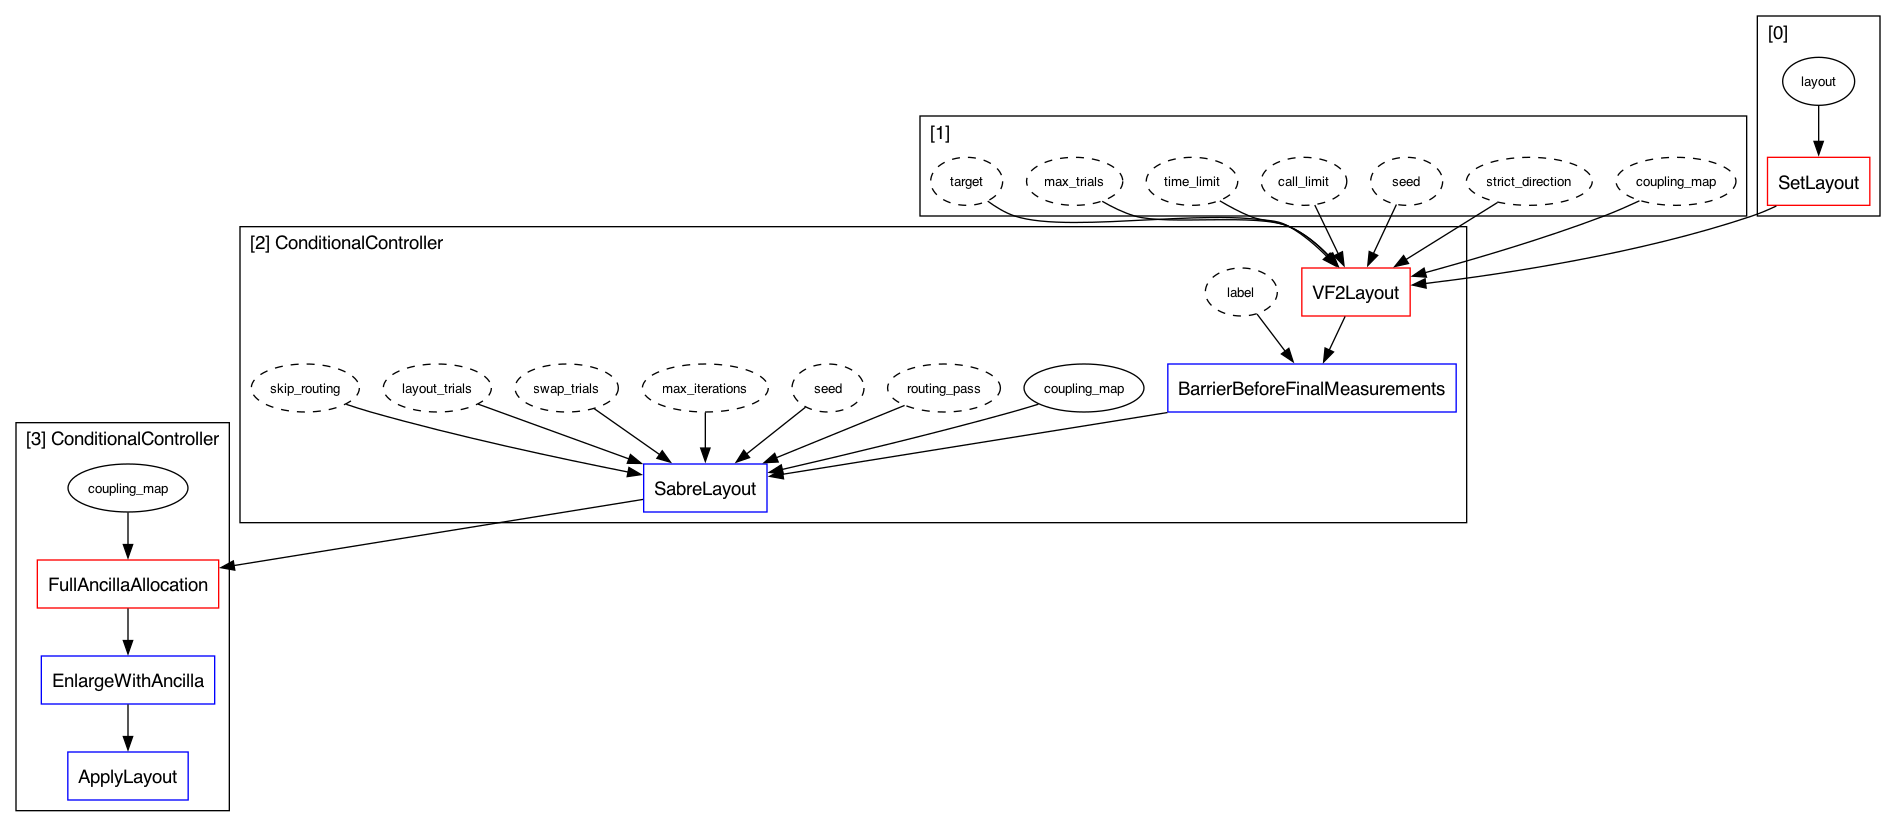

In [ ]:
pm = generate_preset_pass_manager(optimization_level=3, coupling_map=coupling_map, seed_transpiler=random_seed)
vf2_layout = VF2Layout(coupling_map=coupling_map, seed=1)
pm.layout.replace(1, vf2_layout)


Define callback function to get info of the passes during transpilation, in particular the VF2Layout and PostVF2Layout passes. 

In [5]:
passes = []
def callback_func(**kwargs):
    dag_name = kwargs['dag'].name
    t_pass_name = kwargs['pass_'].name()
    t_property = kwargs['property_set']

    # Record the pass name with its corresponding property set
    passes.append((dag_name, t_pass_name, t_property))


Run circuit

In [6]:
passes = []

for qasm_file in circuit_files:
    qc = QuantumCircuit.from_qasm_file(qasm_file)
    qc.name = qasm_file.stem
    qc_tr = pm.run(qc, callback=callback_func, output_name=qc.name)
    
    swaps = count_swaps(qc_tr)
    depth_2q = qc_tr.depth(lambda x: x.operation.num_qubits == 2)
    print(f"{qc.name:<20} {swaps:>6} swaps, {depth_2q:>6} 2q depth")


swap_test_n83             0 swaps,      0 2q depth
knn_67                    0 swaps,      0 2q depth
dnn_n51                   6 swaps,     65 2q depth
ghz_n78                   0 swaps,     77 2q depth
ising_n98                 0 swaps,      4 2q depth
multiplier_n45            0 swaps,    234 2q depth
cat_n65                   0 swaps,     64 2q depth


In [7]:

curr_dag = None
for dag_name, pass_name, property_set in passes:
    if curr_dag != dag_name:
        curr_dag = dag_name
        print(f"Circuit: {dag_name}")
    if pass_name == "VF2Layout":
        print(f"  Pass: {pass_name}")
        print(f"    Stop reason: {property_set['VF2Layout_stop_reason']}")
    elif pass_name == "VF2PostLayout":
        print(f"  Pass: {pass_name}")
        print(f"    Stop reason: {property_set['VF2PostLayout_stop_reason']}")

Circuit: swap_test_n83
  Pass: VF2Layout
    Stop reason: VF2LayoutStopReason.MORE_THAN_2Q
  Pass: VF2PostLayout
    Stop reason: VF2PostLayoutStopReason.MORE_THAN_2Q
  Pass: VF2PostLayout
    Stop reason: VF2PostLayoutStopReason.MORE_THAN_2Q
Circuit: knn_67
  Pass: VF2Layout
    Stop reason: VF2LayoutStopReason.MORE_THAN_2Q
  Pass: VF2PostLayout
    Stop reason: VF2PostLayoutStopReason.MORE_THAN_2Q
  Pass: VF2PostLayout
    Stop reason: VF2PostLayoutStopReason.MORE_THAN_2Q
Circuit: dnn_n51
  Pass: VF2Layout
    Stop reason: VF2LayoutStopReason.MORE_THAN_2Q
  Pass: VF2PostLayout
    Stop reason: VF2PostLayoutStopReason.MORE_THAN_2Q
  Pass: VF2PostLayout
    Stop reason: VF2PostLayoutStopReason.MORE_THAN_2Q
Circuit: ghz_n78
  Pass: VF2Layout
    Stop reason: VF2LayoutStopReason.SOLUTION_FOUND
  Pass: VF2PostLayout
    Stop reason: VF2PostLayoutStopReason.NO_SOLUTION_FOUND
Circuit: ising_n98
  Pass: VF2Layout
    Stop reason: VF2LayoutStopReason.SOLUTION_FOUND
  Pass: VF2PostLayout
    S